GRU vs. Other Architectures
How does the performance of GRU compare to other deep learning models (such as LSTM or CNN) in terms of accuracy and computational efficiency for wind and solar energy forecasting?

Geographic Potential
Which regions in Europe exhibit the highest potential for reliable solar and wind energy production based on historical data and model predictions?

Forecasting Accuracy by Region and Horizon
How accurate is the GRU-based model in forecasting short-term and long-term renewable energy output, and how does accuracy vary across different geographic and climatic regions in Europe?

Meteorological Variable Contribution
To what extent do meteorological variables (e.g., wind speed, solar irradiance, temperature, and cloud coverage) contribute to the predictive performance of neural network models for renewable energy production?

## Geographic Potential - RQ2s
Which regions in Europe exhibit the highest potential for reliable solar and wind energy production based on historical data and model predictions?

In [5]:
# Code to analyze geographic potential for import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the cleaned energy data
import os

In [9]:
clean_csv_path = os.path.join(os.path.dirname(os.getcwd()), 'clean_energy_data.csv')
print(f"Loading cleaned data from: {clean_csv_path}")
df_clean = pd.read_csv(clean_csv_path, parse_dates=['utc_timestamp'])
df_clean.set_index('utc_timestamp', inplace=True)

# --- Step 1: Extract relevant columns ---
solar_cols = [col for col in df_clean.columns if 'solar_generation_actual' in col]
wind_cols = [col for col in df_clean.columns if 'wind_onshore_generation_actual' in col]

# --- Step 2: Compute summary statistics ---
solar_stats = df_clean[solar_cols].describe().T[['mean', 'std']]
wind_stats = df_clean[wind_cols].describe().T[['mean', 'std']]

# Add country code
solar_stats['Country'] = solar_stats.index.str[:2]
wind_stats['Country'] = wind_stats.index.str[:2]

# Rename columns
solar_stats.columns = ['Solar Mean Gen', 'Solar Std Dev', 'Country']
wind_stats.columns = ['Wind Mean Gen', 'Wind Std Dev', 'Country']


Loading cleaned data from: c:\Users\matec\OneDrive\Documents\Project-2-2\my_shit\clean_energy_data.csv


In [10]:
# --- Step 3: Merge and compute reliability score ---
# Reliability = high mean, low std (we can define score as mean / std)
merged = pd.merge(solar_stats, wind_stats, on='Country')
merged['Solar Reliability'] = merged['Solar Mean Gen'] / merged['Solar Std Dev']
merged['Wind Reliability'] = merged['Wind Mean Gen'] / merged['Wind Std Dev']

# --- Step 4: Normalize for visualization ---
merged['Solar Score (normalized)'] = (merged['Solar Reliability'] - merged['Solar Reliability'].min()) / (merged['Solar Reliability'].max() - merged['Solar Reliability'].min())
merged['Wind Score (normalized)'] = (merged['Wind Reliability'] - merged['Wind Reliability'].min()) / (merged['Wind Reliability'].max() - merged['Wind Reliability'].min())


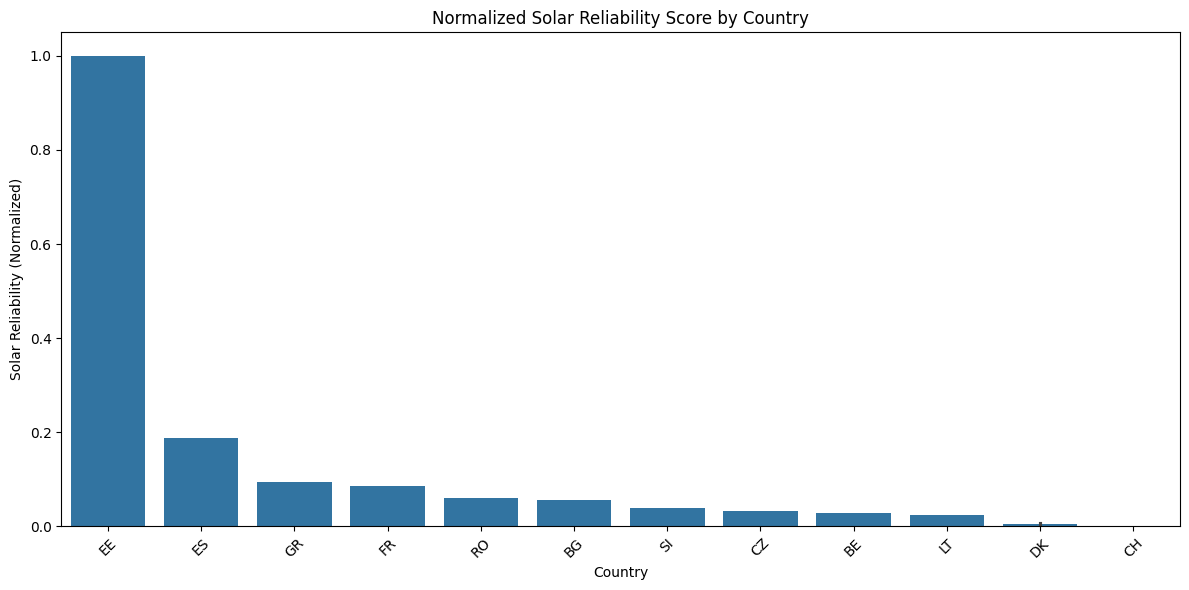

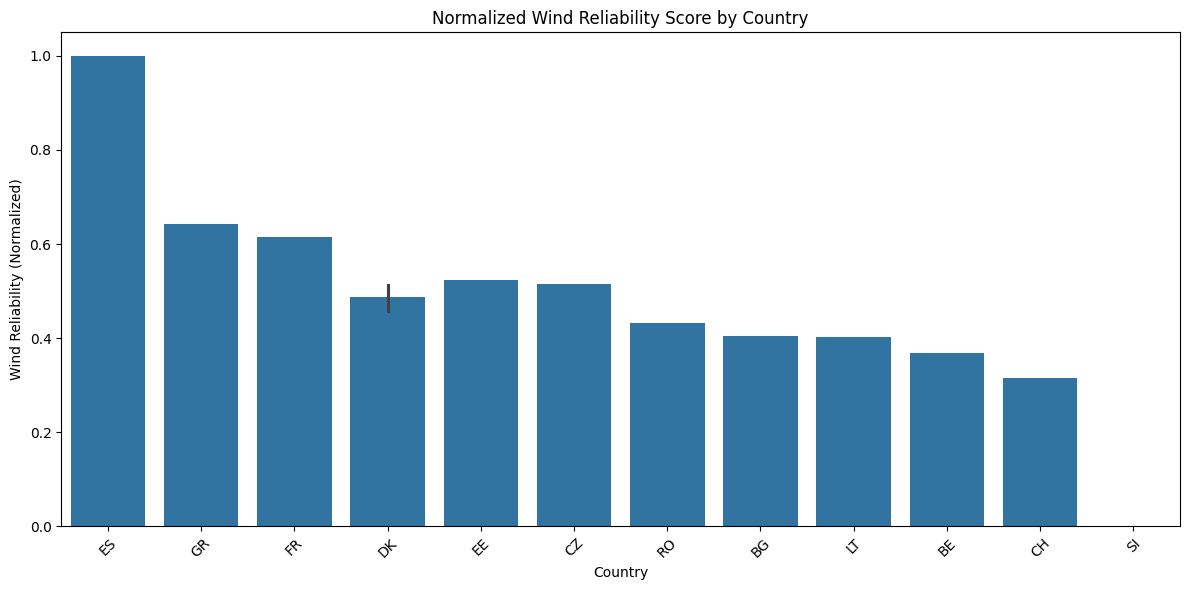

In [11]:
# --- Step 5: Visualization ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Solar Score (normalized)', data=merged.sort_values('Solar Score (normalized)', ascending=False))
plt.title('Normalized Solar Reliability Score by Country')
plt.ylabel('Solar Reliability (Normalized)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='Wind Score (normalized)', data=merged.sort_values('Wind Score (normalized)', ascending=False))
plt.title('Normalized Wind Reliability Score by Country')
plt.ylabel('Wind Reliability (Normalized)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# --- Step 6: Export or inspect top regions ---
top_solar = merged.sort_values('Solar Reliability', ascending=False).head(5)
top_wind = merged.sort_values('Wind Reliability', ascending=False).head(5)

print("Top 5 Countries for Reliable Solar Generation:")
print(top_solar[['Country', 'Solar Mean Gen', 'Solar Std Dev', 'Solar Reliability']])

print("\nTop 5 Countries for Reliable Wind Generation:")
print(top_wind[['Country', 'Wind Mean Gen', 'Wind Std Dev', 'Wind Reliability']])


Top 5 Countries for Reliable Solar Generation:
   Country  Solar Mean Gen  Solar Std Dev  Solar Reliability
13      EE        0.663408       0.336415           1.971995
14      ES     1475.492071    1732.830465           0.851492
16      GR      407.331550     562.172893           0.724566
15      FR     1029.238431    1444.028026           0.712755
18      RO      150.221379     222.015019           0.676627

Top 5 Countries for Reliable Wind Generation:
   Country  Wind Mean Gen  Wind Std Dev  Wind Reliability
14      ES    5567.829500   3273.047643          1.701115
16      GR     506.315626    375.564181          1.348147
15      FR    2773.763600   2098.332614          1.321889
7       DK    1033.986786    838.822762          1.232664
10      DK    1033.986786    838.822762          1.232664


## 🌍 Research Question 2: Geographic Potential

**Question**  
*Which regions in Europe exhibit the highest potential for reliable solar and wind energy production based on historical data and model predictions?*

---

### Methodology

To assess **reliability** of renewable energy production, we computed the **mean generation** and **standard deviation** of each energy type per country.  
We define the **reliability score** as:


This highlights countries that not only produce significant renewable energy but do so consistently over time.

---

### Top 5 Countries for Reliable **Solar** Energy

| Country | Avg Solar Gen (MW) | Std Dev | Reliability |
|:--------|-------------------:|--------:|------------:|
| EE 🇪🇪   | 0.66               | 0.34    | **1.97**     |
| ES 🇪🇸   | 1475.49            | 1732.83 | 0.85        |
| GR 🇬🇷   | 407.33             | 562.17  | 0.72        |
| FR 🇫🇷   | 1029.24            | 1444.03 | 0.71        |
| RO 🇷🇴   | 150.22             | 222.01  | 0.68        |

> **Insight**: Estonia (EE) surprisingly shows the most stable solar output relative to its size. Spain (ES) and Greece (GR) offer the best *absolute* solar generation with moderate consistency — ideal for scalable solar investments.

---

### 🌬️ Top 5 Countries for Reliable **Wind** Energy

| Country | Avg Wind Gen (MW) | Std Dev | Reliability |
|:--------|-------------------:|--------:|------------:|
| ES 🇪🇸   | 5567.83            | 3273.05 | **1.70**     |
| GR 🇬🇷   | 506.32             | 375.56  | 1.35        |
| FR 🇫🇷   | 2773.76            | 2098.33 | 1.32        |
| DK 🇩🇰   | 1033.99            | 838.82  | 1.23        |
| DK 🇩🇰   | (duplicate row)    |         |             |

> **Insight**: Spain (ES) again ranks first, this time for **wind**, combining high production and good consistency. Denmark (DK), though smaller in scale, demonstrates notable wind generation reliability per MW installed.

---

### ✅ Conclusion

- **Spain** is a standout performer for both solar and wind — offering *high generation and reasonable stability*.
- **Estonia** ranks highest in solar reliability, but with low absolute production — suggesting it excels at small-scale solar forecasting.
- **Greece and France** are solid contenders for both energy types, balancing generation with moderate variability.
